# 🚢 Feature Engineering on the Titanic Dataset

**Feature engineering** is the process of creating, transforming, or selecting input variables from raw data to improve a machine learning model's performance.  
The Titanic dataset is a classic playground for practicing these techniques because it contains a rich mix of numeric, categorical, and missing-heavy columns.

> **Data source:** `seaborn.load_dataset("titanic")` — no CSV needed.

---

## 📋 Table of Contents

| # | Section | Technique |
|---|---------|-----------|
| 1 | Setup & Load | `seaborn.load_dataset` |
| 2 | Data Dictionary | Column definitions |
| 3 | EDA | Shape, dtypes, missing values, distributions |
| 4 | Missing Value Handling | Median / mode imputation, missing-as-information |
| 5 | Domain-Knowledge Features | Family size, is_alone, family group |
| 6 | Title / Social Status Feature | Derived from sex + who + pclass |
| 7 | Binning | Age groups (uniform), fare groups (quantile) |
| 8 | Boolean / Rule-Based | is_child, is_female, is_first_class, is_high_fare |
| 9 | Numeric Transformations | Fare per person, log-fare, fare-vs-class ratio |
| 10 | Interaction Features | sex × class, age × class |
| 11 | Encoding | One-hot, ordinal, binary mapping |
| 12 | Correlation Analysis | Which features predict survival? |
| 13 | Final Summary | Complete engineered DataFrame |

---


## 1. 📦 Imports & Global Style

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (9, 4)})

print("Libraries loaded ✅")


Libraries loaded ✅


## 2. 📂 Load the Titanic Dataset

`seaborn.load_dataset("titanic")` returns 891 rows and 15 columns.  
It is Kaggle's training split with several pre-processed helper columns added by seaborn.


In [12]:
# df_raw = sns.load_dataset("titanic")
df_raw = pd.read_csv("data_titanic_kaggle.csv")
df = df_raw.copy()

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(10)


Shape: (891, 12)
Columns: ['passengerId', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked']


,passengerId,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


## 3. 📖 Data Dictionary
| Column          | Meaning                                                              |
| --------------- | -------------------------------------------------------------------- |
| **passengerId** | Unique ID assigned to each passenger                                 |
| **survived**    | Survival outcome (0 = No, 1 = Yes)                                   |
| **pclass**      | Passenger class (1 = 1st, 2 = 2nd, 3 = 3rd)                          |
| **name**        | Full name of the passenger (often includes title)                    |
| **sex**         | Gender of the passenger                                              |
| **age**         | Age in years (some values missing)                                   |
| **sibp**       | Number of siblings or spouses aboard                                 |
| **parch**       | Number of parents or children aboard                                 |
| **ticket**      | Ticket number                                                        |
| **fare**        | Amount paid for the ticket                                           |
| **cabin**       | Cabin number (many missing values)                                   |
| **embarked**    | Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton) |


## 4. 🔍 Exploratory Data Analysis

In [13]:
print("── dtypes ──")
print(df.dtypes)
print()
print("── Missing Values ──")
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)
print(pd.DataFrame({"count": miss, "pct%": miss_pct})[miss > 0])


── dtypes ──
passengerId      int64
survived         int64
pclass           int64
name            object
sex             object
age            float64
sibsp            int64
parch            int64
ticket          object
fare           float64
cabin           object
embarked        object
dtype: object

── Missing Values ──
          count  pct%
age         177  19.9
cabin       687  77.1
embarked      2   0.2


In [4]:
print(df.describe())

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


C:\Users\hi\AppData\Local\Temp\ipykernel_15156\293049189.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="sex", y="survived", palette="Set1", ax=axes[1])
C:\Users\hi\AppData\Local\Temp\ipykernel_15156\293049189.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="pclass", y="survived", palette="Blues_r", ax=axes[2])


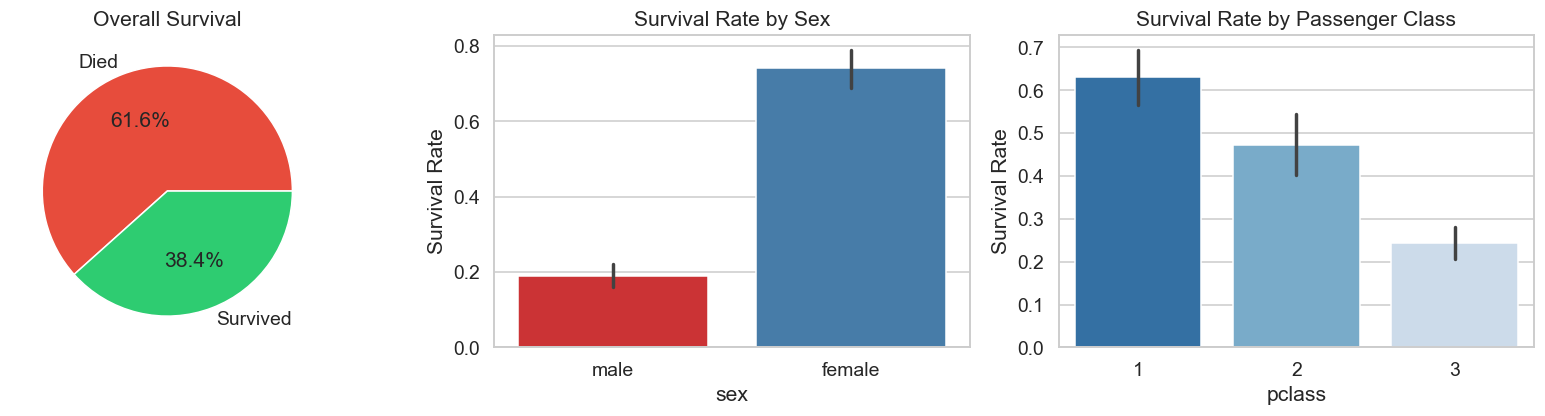

In [14]:
# Survival overview
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["survived"].value_counts().plot.pie(
    labels=["Died", "Survived"], autopct="%1.1f%%",
    colors=["#e74c3c", "#2ecc71"], ax=axes[0]
)
axes[0].set_title("Overall Survival")
axes[0].set_ylabel("")

sns.barplot(data=df, x="sex", y="survived", palette="Set1", ax=axes[1])
axes[1].set_title("Survival Rate by Sex")
axes[1].set_ylabel("Survival Rate")

sns.barplot(data=df, x="pclass", y="survived", palette="Blues_r", ax=axes[2])
axes[2].set_title("Survival Rate by Passenger Class")
axes[2].set_ylabel("Survival Rate")

plt.tight_layout()
plt.show()


C:\Users\hi\AppData\Local\Temp\ipykernel_15156\79294230.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sibsp", palette="Purples", ax=axes[1][0])
C:\Users\hi\AppData\Local\Temp\ipykernel_15156\79294230.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="parch", palette="Greens", ax=axes[1][1])


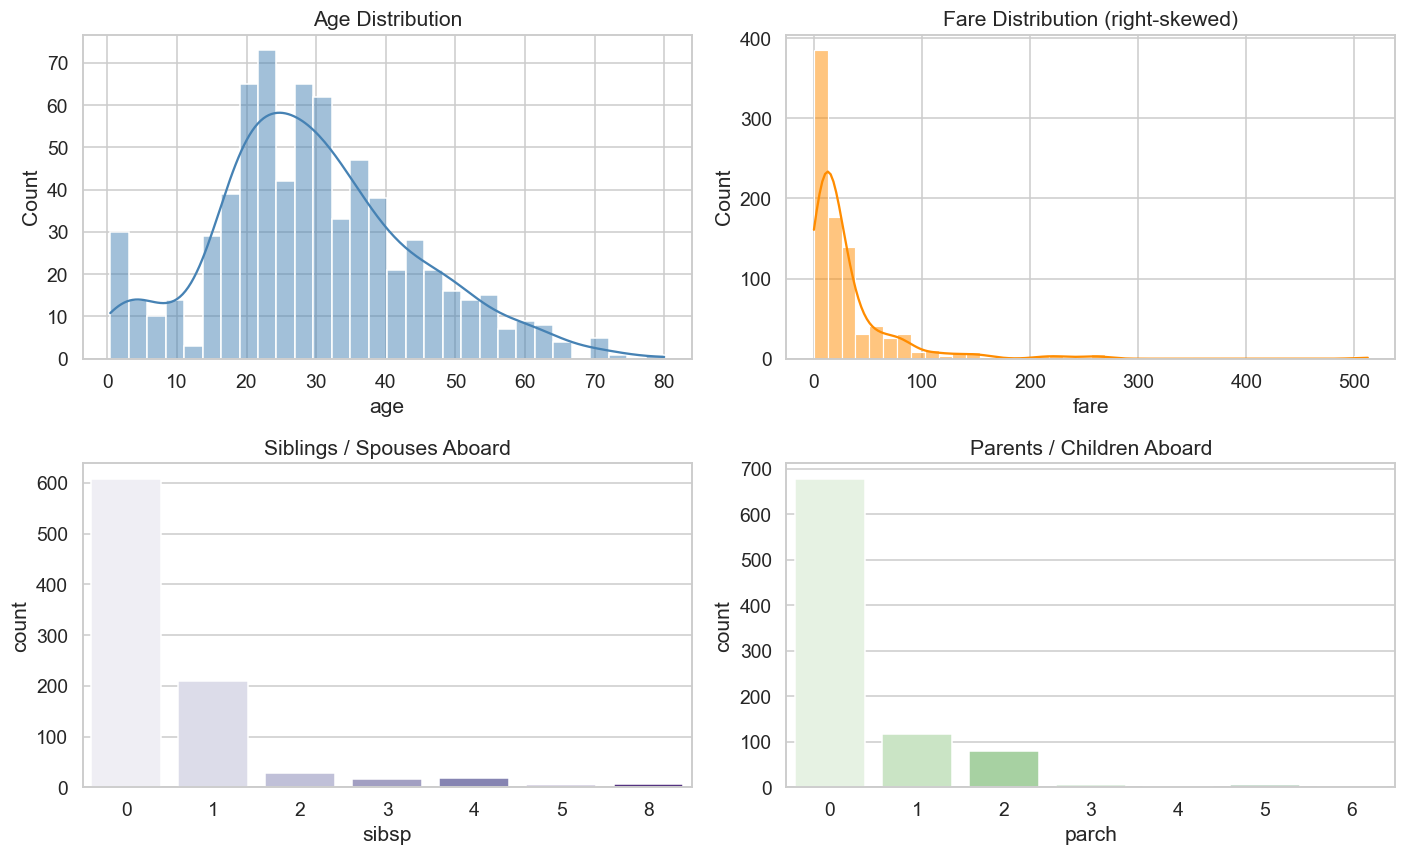

In [15]:
# Numeric distributions
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.histplot(df["age"].dropna(), kde=True, bins=30, ax=axes[0][0], color="steelblue")
axes[0][0].set_title("Age Distribution")

sns.histplot(df["fare"].dropna(), kde=True, bins=40, ax=axes[0][1], color="darkorange")
axes[0][1].set_title("Fare Distribution (right-skewed)")

sns.countplot(data=df, x="sibsp", palette="Purples", ax=axes[1][0])
axes[1][0].set_title("Siblings / Spouses Aboard")

sns.countplot(data=df, x="parch", palette="Greens", ax=axes[1][1])
axes[1][1].set_title("Parents / Children Aboard")

plt.tight_layout()
plt.show()


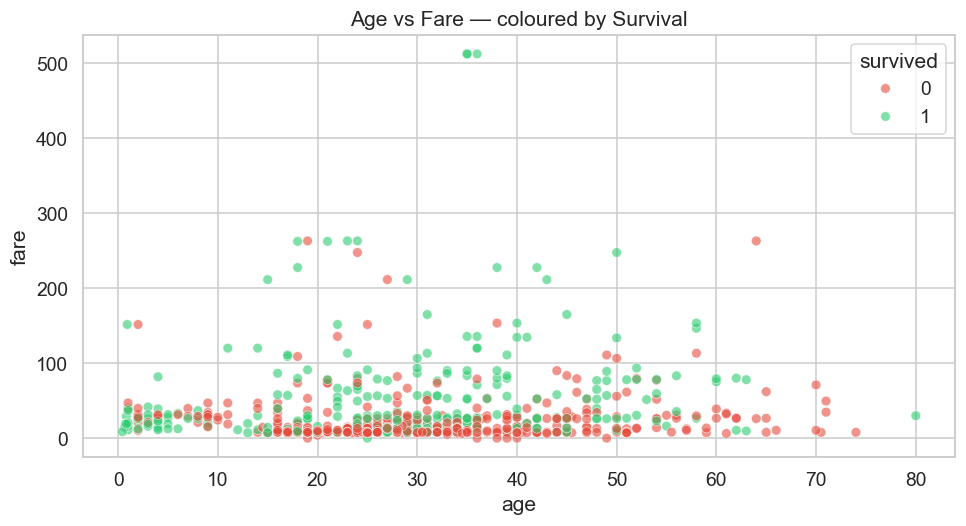

In [16]:
# Age vs Fare coloured by survival
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x="age", y="fare", hue="survived",
                palette={0: "#e74c3c", 1: "#2ecc71"}, alpha=0.6, s=40)
plt.title("Age vs Fare — coloured by Survival")
plt.tight_layout()
plt.show()


C:\Users\hi\AppData\Local\Temp\ipykernel_15156\2524468085.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="embarked", y="survived",


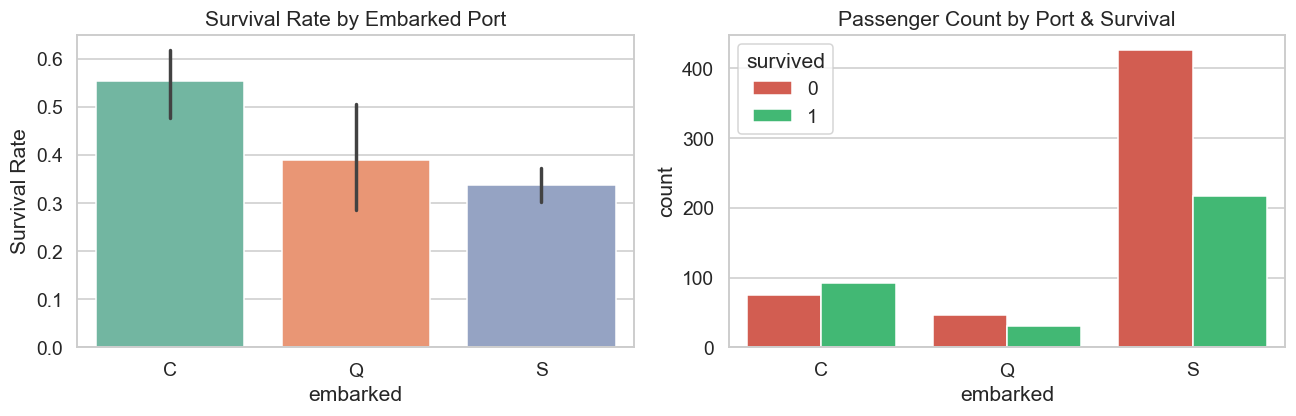

In [17]:
# Survival rate by embarkation port
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=df, x="embarked", y="survived",
            order=["C", "Q", "S"], palette="Set2", ax=axes[0])
axes[0].set_title("Survival Rate by Embarked Port")
axes[0].set_ylabel("Survival Rate")

sns.countplot(data=df, x="embarked", order=["C", "Q", "S"],
              hue="survived", palette={0:"#e74c3c", 1:"#2ecc71"}, ax=axes[1])
axes[1].set_title("Passenger Count by Port & Survival")

plt.tight_layout()
plt.show()


## 5. 🧹 Handle Missing Values

| Column | Missing | Strategy |
|--------|---------|----------|
| `age` | 177 (19.9%) | Median imputation |
| `embarked` | 2 (0.2%) | Mode imputation |
| `cabin` | 687 (77.2%) | Extract `has_cabin` flag, then drop |
| `embark_town` | 2 (0.2%) | Duplicate of `embarked` — drop |

> **Key insight:** Missing `deck` is informative — lower-class passengers rarely had assigned cabins.


In [19]:
# 1) How many missing values ?

missing = df.isna().sum()
print(missing)

passengerId      0
survived         0
pclass           0
name             0
sex              0
age            177
sibsp            0
parch            0
ticket           0
fare             0
cabin          687
embarked         2
dtype: int64


In [21]:
df['has_cabin'] = df['cabin'].notna().astype(int)

C:\Users\hi\AppData\Local\Temp\ipykernel_15156\2851466426.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="has_cabin", y="survived",


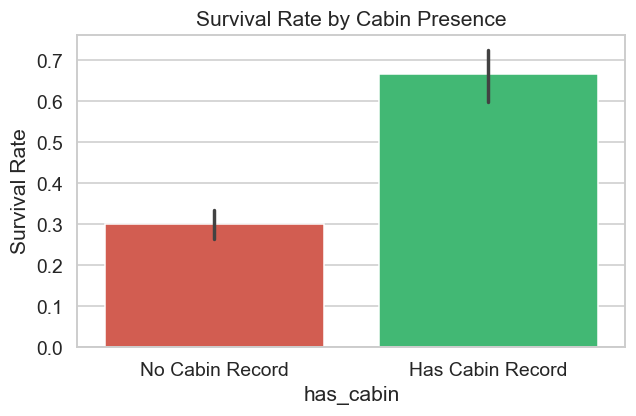

In [22]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="has_cabin", y="survived",
            palette=["#e74c3c", "#2ecc71"])
plt.xticks([0, 1], ["No Cabin Record", "Has Cabin Record"])
plt.title("Survival Rate by Cabin Presence")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()

In [11]:
# ── Imputation ──
age_median = df["age"].median()
df["age"] = df["age"].fillna(age_median)
print(f"Age: filled {df_raw['age'].isna().sum()} NaNs with median {age_median:.1f}")

mode_emb = df["embarked"].mode()[0]
df["embarked"] = df["embarked"].fillna(mode_emb)
print(f"Embarked: filled missing with mode '{mode_emb}'")

# Drop columns we won't use
df.drop(columns=["deck", "embark_town", "alive", "class"], inplace=True)

print()
print("Missing after imputation:")
remaining = df.isnull().sum()
print(remaining[remaining > 0] if remaining.any() else "None ✅")


Age: filled 177 NaNs with median 28.0
Embarked: filled missing with mode 'S'

Missing after imputation:
None ✅


## 6. 👨‍👩‍👧 Domain-Knowledge Features

### 6a. Family Size
Passengers traveling with family behaved differently during evacuation.  
Small families had the highest survival — large groups got separated, solo travelers were deprioritised.


In [23]:
df

,passengerId,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,has_cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1


In [24]:
df['family_size'] = df['sibsp'] + df['parch'] + 1   # +1 = the passenger themselves

print("── Value Counts ──")
print(df["family_size"].value_counts().sort_index())
print()
print("── Survival Rate by Family Size ──")
print(df.groupby("family_size")["survived"].mean().round(3))


── Value Counts ──
family_size
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

── Survival Rate by Family Size ──
family_size
1     0.304
2     0.553
3     0.578
4     0.724
5     0.200
6     0.136
7     0.333
8     0.000
11    0.000
Name: survived, dtype: float64


C:\Users\hi\AppData\Local\Temp\ipykernel_15156\1019628816.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="family_size", palette="Blues", ax=axes[0])
C:\Users\hi\AppData\Local\Temp\ipykernel_15156\1019628816.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=family_surv, x="family_size", y="survived",


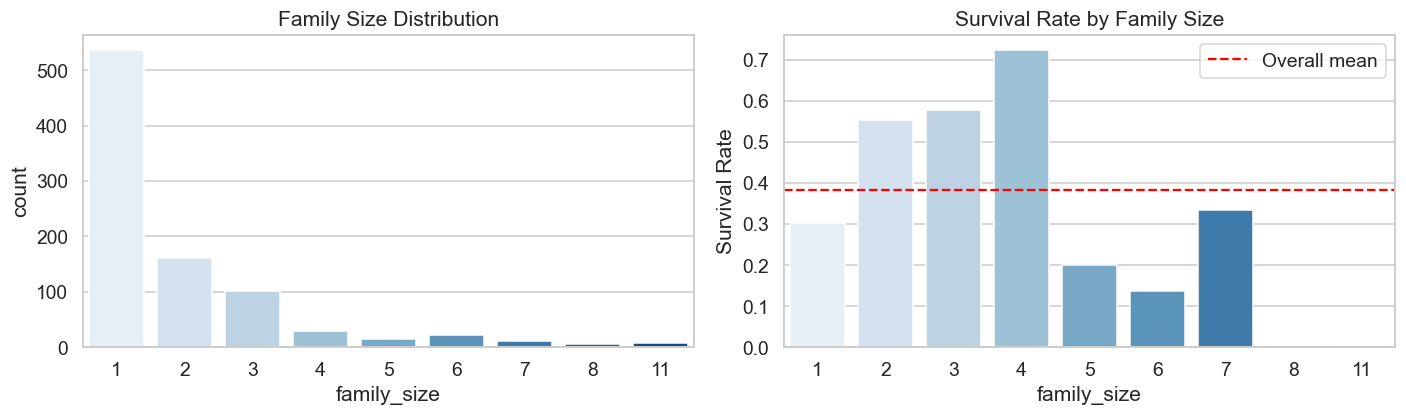

Observation: family sizes 2–4 had the best survival; solo travelers and families of 5+ fared worst.


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(data=df, x="family_size", palette="Blues", ax=axes[0])
axes[0].set_title("Family Size Distribution")

family_surv = df.groupby("family_size")["survived"].mean().reset_index()
sns.barplot(data=family_surv, x="family_size", y="survived",
            palette="Blues", ax=axes[1])
axes[1].axhline(df["survived"].mean(), color="red", linestyle="--", label="Overall mean")
axes[1].legend()
axes[1].set_title("Survival Rate by Family Size")
axes[1].set_ylabel("Survival Rate")

plt.tight_layout()
plt.show()

print("Observation: family sizes 2–4 had the best survival; solo travelers and families of 5+ fared worst.")


### 6b. Is Alone
- Create a new column is_alone.
- If family_size ==1, then he is alone.
- 0 means not alone, 1 means passenger is alone

In [26]:
df["is_alone"] = (df["family_size"] == 1).astype(int)

print(df["is_alone"].value_counts())
print()
print("Survival rate — alone vs not alone:")
print(df.groupby("is_alone")["survived"].mean().round(3))

is_alone
1    537
0    354
Name: count, dtype: int64

Survival rate — alone vs not alone:
is_alone
0    0.506
1    0.304
Name: survived, dtype: float64


#### Note:
* Convert logic → numeric
* Binary features are ML-friendly

## Feature from Text

### **Title from Name**

**Why?**
- Titles encode **gender, age, and social status**.


In [27]:
print(df['name'].sample(7))

485         Lefebre, Miss. Jeannie
479       Hirvonen, Miss. Hildur E
770         Lievens, Mr. Rene Aime
445      Dodge, Master. Washington
155    Williams, Mr. Charles Duane
569              Jonsson, Mr. Carl
203           Youseff, Mr. Gerious
Name: name, dtype: object


In [28]:
# df['title'] = df['name'].str.extract(r',\s*([^\.]+)\.')
df["title"] = df["name"].apply(lambda x: x.split(",")[1].split(".")[0])
df['title'] = df['title'].str.strip()

# Check:
print(df['title'].value_counts())

title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64


In [29]:
# Lets check

print(df[['name', 'title']].sample(10))

                                         name title
43   Laroche, Miss. Simonne Marie Anne Andree  Miss
55                          Woolner, Mr. Hugh    Mr
115                     Pekoniemi, Mr. Edvard    Mr
468                        Scanlan, Mr. James    Mr
704                   Hansen, Mr. Henrik Juul    Mr
169                             Ling, Mr. Lee    Mr
463              Milling, Mr. Jacob Christian    Mr
552                      O'Brien, Mr. Timothy    Mr
422                        Zimmerman, Mr. Leo    Mr
337           Burns, Miss. Elizabeth Margaret  Miss


---

### **Group Rare Titles**


In [31]:
rare_titles = [
    'Dr', 'Rev', 'Major', 'Col', 'Capt', 'Don',
    'Sir', 'Lady', 'the Countess', 'Jonkheer'
]

df.loc[df['title'].isin(rare_titles), 'title'] = 'Rare'
print(df.sample(5))

     passengerId  survived  pclass                          name     sex  \
855          856         1       3    Aks, Mrs. Sam (Leah Rosen)  female   
682          683         0       3   Olsvigen, Mr. Thor Anderson    male   
708          709         1       1          Cleaver, Miss. Alice  female   
792          793         0       3       Sage, Miss. Stella Anna  female   
66            67         1       2  Nye, Mrs. (Elizabeth Ramell)  female   

      age  sibsp  parch      ticket     fare cabin embarked  has_cabin  \
855  18.0      0      1      392091    9.350   NaN        S          0   
682  20.0      0      0        6563    9.225   NaN        S          0   
708  22.0      0      0      113781  151.550   NaN        S          0   
792   NaN      8      2    CA. 2343   69.550   NaN        S          0   
66   29.0      0      0  C.A. 29395   10.500   F33        S          1   

     family_size  is_alone title  
855            2         0   Mrs  
682            1         1  

Why ?

> Reduce noise by grouping rare categories.

### Create surnames

In [32]:
df['Surname'] = df['name'].str.split(',').str[0]
print(df['Surname'].nunique())

667


In [33]:
print(df.sample(10))

     passengerId  survived  pclass  \
66            67         1       2   
573          574         1       3   
710          711         1       1   
294          295         0       3   
848          849         0       2   
216          217         1       3   
470          471         0       3   
570          571         1       2   
493          494         0       1   
782          783         0       1   

                                                 name     sex   age  sibsp  \
66                       Nye, Mrs. (Elizabeth Ramell)  female  29.0      0   
573                                 Kelly, Miss. Mary  female   NaN      0   
710  Mayne, Mlle. Berthe Antonine ("Mrs de Villiers")  female  24.0      0   
294                                  Mineff, Mr. Ivan    male  24.0      0   
848                                 Harper, Rev. John    male  28.0      0   
216                            Honkanen, Miss. Eliina  female  27.0      0   
470                                

### 6c. Family Group (Categorical)

C:\Users\hi\AppData\Local\Temp\ipykernel_15156\3493439286.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="family_group", y="survived", order=order, palette="Set2")


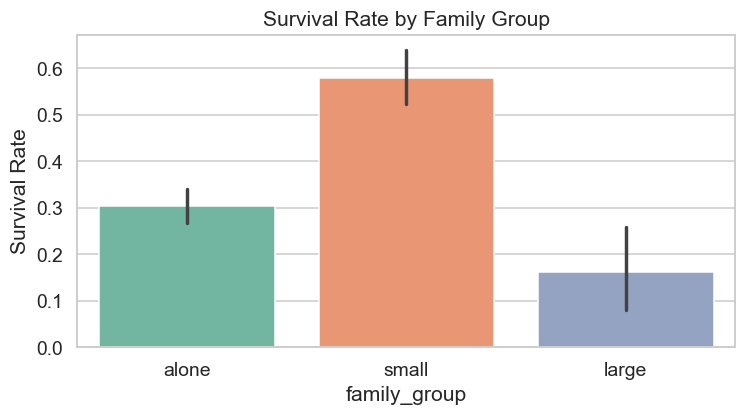

In [34]:
def family_group(n):
    if n == 1:  return "alone"
    if n <= 4:  return "small"
    return "large"

df["family_group"] = df["family_size"].apply(family_group)

order = ["alone", "small", "large"]
plt.figure(figsize=(7, 4))
sns.barplot(data=df, x="family_group", y="survived", order=order, palette="Set2")
plt.title("Survival Rate by Family Group")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()


In [7]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size,family_group
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2,small
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2,small
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1,alone
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2,small
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1,alone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,1,alone
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,1,alone
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,4,small
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,1,alone


## 8. 📊 Binning (Discretisation)

### 8a. Age Groups — Uniform Bins


**Why?**
- Models often learn better from age categories.

```
(0, 12]   -> Child
(12, 18]  -> Teen
(18, 60]  -> Adult
(60, 100] -> Senior
```


In [36]:
df

,passengerId,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,has_cabin,family_size,is_alone,title,Surname,family_group
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,2,0,Mr,Braund,small
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,2,0,Mrs,Cumings,small
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,1,Miss,Heikkinen,alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,2,0,Mrs,Futrelle,small
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0,1,1,Mr,Allen,alone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,0,1,1,Rare,Montvila,alone
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1,1,1,Miss,Graham,alone
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,0,4,0,Miss,Johnston,small
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1,1,1,Mr,Behr,alone


In [37]:
df["age_group"] = pd.cut(
    df["age"],
    bins   =[0,        12,     18,     60,      100],
    labels =["Child", "Teen", "Adult", "Senior"],
    include_lowest=True
)

print("── Value Counts ──")
print(df["age_group"].value_counts())
print()
print("── Survival Rate by Age Group ──")
print(df.groupby("age_group", observed=True)["survived"].mean().round(3))


── Value Counts ──
age_group
Adult     553
Teen       70
Child      69
Senior     22
Name: count, dtype: int64

── Survival Rate by Age Group ──
age_group
Child     0.580
Teen      0.429
Adult     0.389
Senior    0.227
Name: survived, dtype: float64


C:\Users\hi\AppData\Local\Temp\ipykernel_15156\2585472195.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="age_group", y="survived", order=ag_order,
C:\Users\hi\AppData\Local\Temp\ipykernel_15156\2585472195.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="age_group", y="fare", order=ag_order,


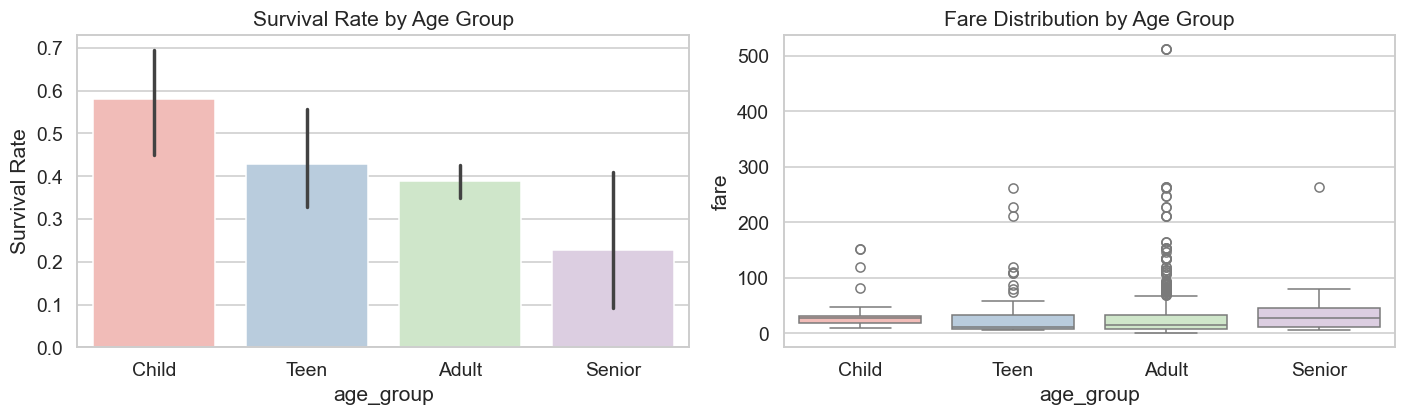

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ag_order = ["Child", "Teen", "Adult", "Senior"]

sns.barplot(data=df, x="age_group", y="survived", order=ag_order,
            palette="Pastel1", ax=axes[0])
axes[0].set_title("Survival Rate by Age Group")
axes[0].set_ylabel("Survival Rate")

sns.boxplot(data=df, x="age_group", y="fare", order=ag_order,
            palette="Pastel1", ax=axes[1])
axes[1].set_title("Fare Distribution by Age Group")

plt.tight_layout()
plt.show()


### 8b. Fare Groups — Quantile Bins (Equal-Frequency)

In [39]:
df

,passengerId,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,has_cabin,family_size,is_alone,title,Surname,family_group,age_group
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,2,0,Mr,Braund,small,Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,2,0,Mrs,Cumings,small,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,1,Miss,Heikkinen,alone,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,2,0,Mrs,Futrelle,small,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0,1,1,Mr,Allen,alone,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,0,1,1,Rare,Montvila,alone,Adult
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1,1,1,Miss,Graham,alone,Adult
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,0,4,0,Miss,Johnston,small,NaN
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1,1,1,Mr,Behr,alone,Adult


In [40]:
df["fare_group"] = pd.qcut(df["fare"], q=4,
                            labels=["budget", "economy", "comfort", "luxury"])

print("── Value Counts ──")
print(df["fare_group"].value_counts())
print()
print("── Survival Rate by Fare Group ──")
print(df.groupby("fare_group", observed=True)["survived"].mean().round(3))


── Value Counts ──
fare_group
economy    224
budget     223
comfort    222
luxury     222
Name: count, dtype: int64

── Survival Rate by Fare Group ──
fare_group
budget     0.197
economy    0.304
comfort    0.455
luxury     0.581
Name: survived, dtype: float64


In [ ]:
fare_order = ["budget", "economy", "comfort", "luxury"]
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x="fare_group", y="survived", order=fare_order, palette="YlOrRd")
plt.title("Survival Rate by Fare Group")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()


# STOPPED HERE

## 9. ✅ Boolean / Rule-Based Features

Simple threshold rules that encode domain knowledge directly.


In [41]:
df["is_child"]       = (df["age"] < 12).astype(int)
df["is_female"]      = (df["sex"] == "female").astype(int)
df["is_first_class"] = (df["pclass"] == 1).astype(int)
df["is_high_fare"]   = (df["fare"] > df["fare"].median()).astype(int)

for col in ["is_child", "is_female", "is_first_class", "is_high_fare", "has_cabin", "is_alone"]:
    rate = df.groupby(col)["survived"].mean().round(3).to_dict()
    print(f"{col}: {rate}")


is_child: {0: 0.368, 1: 0.574}
is_female: {0: 0.189, 1: 0.742}
is_first_class: {0: 0.305, 1: 0.63}
is_high_fare: {0: 0.251, 1: 0.518}
has_cabin: {0: 0.3, 1: 0.667}
is_alone: {0: 0.506, 1: 0.304}


C:\Users\hi\AppData\Local\Temp\ipykernel_15156\710396927.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate, x=feat, y="survived",
C:\Users\hi\AppData\Local\Temp\ipykernel_15156\710396927.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate, x=feat, y="survived",
C:\Users\hi\AppData\Local\Temp\ipykernel_15156\710396927.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate, x=feat, y="survived",
C:\Users\hi\AppData\Local\Temp\ipykernel_15156\710396927.py:9: FutureWarning: 

Passing `palette` without assigning `hue`

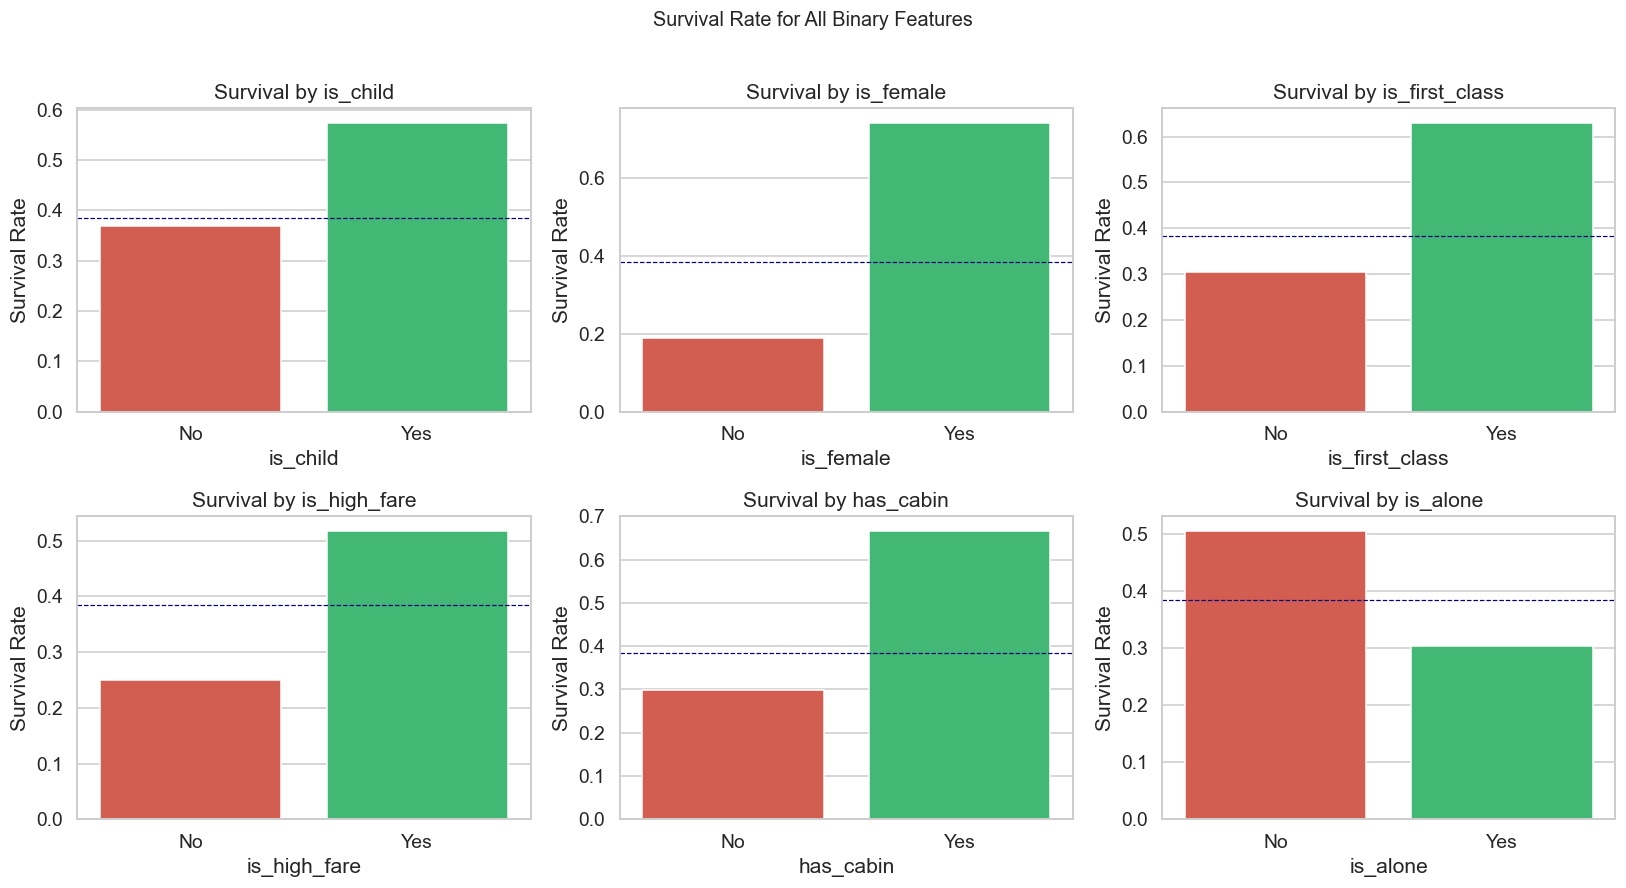

In [42]:
binary_features = ["is_child", "is_female", "is_first_class",
                   "is_high_fare", "has_cabin", "is_alone"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(binary_features):
    rate = df.groupby(feat)["survived"].mean().reset_index()
    sns.barplot(data=rate, x=feat, y="survived",
                palette=["#e74c3c", "#2ecc71"], ax=axes[i])
    axes[i].set_title(f"Survival by {feat}")
    axes[i].set_ylabel("Survival Rate")
    axes[i].axhline(df["survived"].mean(), color="navy", linestyle="--", linewidth=0.8)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["No", "Yes"])

plt.suptitle("Survival Rate for All Binary Features", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 10. 🔢 Numeric Transformations

### 10a. Fare per Person
Group tickets inflate the raw fare — dividing by family size makes it per-person.


In [43]:
df["fare_per_person"] = df["fare"] / df["family_size"]

print(df[["fare", "family_size", "fare_per_person"]].sample(10))


        fare  family_size  fare_per_person
509  56.4958            1        56.495800
806   0.0000            1         0.000000
39   11.2417            2         5.620850
218  76.2917            1        76.291700
424  20.2125            3         6.737500
163   8.6625            1         8.662500
180  69.5500           11         6.322727
419  24.1500            3         8.050000
529  11.5000            4         2.875000
873   9.0000            1         9.000000


### 10b. Log-Fare (Handle Skewness)

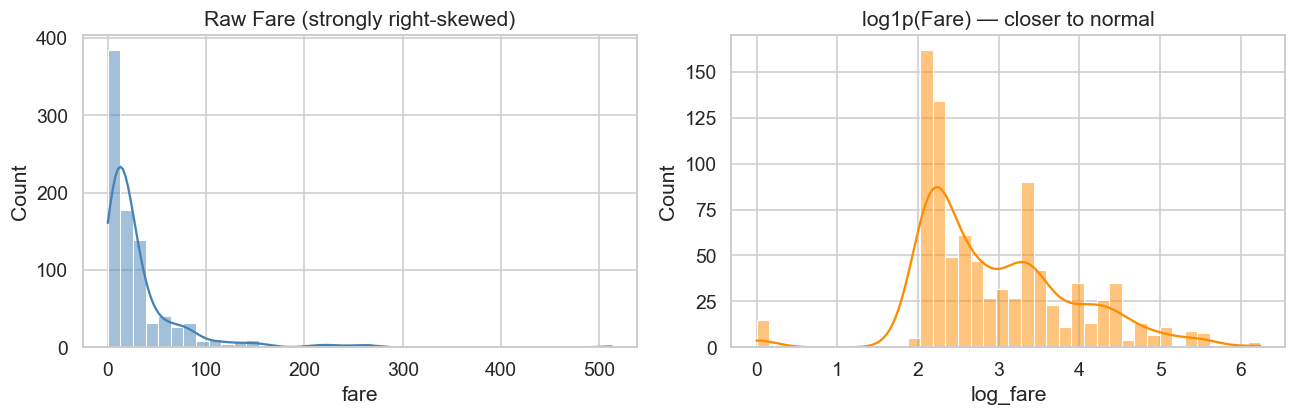

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["fare"], kde=True, bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("Raw Fare (strongly right-skewed)")

df["log_fare"] = np.log1p(df["fare"])
sns.histplot(df["log_fare"], kde=True, bins=40, ax=axes[1], color="darkorange")
axes[1].set_title("log1p(Fare) — closer to normal")

plt.tight_layout()
plt.show()


### 10c. Fare Relative to Class Median

In [45]:
# Did this passenger pay more or less than typical for their class?
class_median = df.groupby("pclass")["fare"].transform("median")
df["fare_vs_class"] = df["fare"] / class_median

print("High value = overpaid vs class peers:")
print(df[["pclass", "fare", "fare_vs_class"]].sort_values("fare_vs_class", ascending=False).head(8))


High value = overpaid vs class peers:
     pclass      fare  fare_vs_class
863       3   69.5500       8.639752
180       3   69.5500       8.639752
846       3   69.5500       8.639752
201       3   69.5500       8.639752
324       3   69.5500       8.639752
792       3   69.5500       8.639752
159       3   69.5500       8.639752
679       1  512.3292       8.498100


## 11. 🔗 Interaction Features

### 11a. Sex × Class
The single most powerful predictor of Titanic survival is the combination of gender and class.


In [46]:
df["sex_class"] = df["sex"].astype(str) + "_" + df["pclass"].astype(str)

sc_surv = (df.groupby("sex_class")["survived"]
             .mean()
             .sort_values(ascending=False)
             .reset_index())
print(sc_surv)


  sex_class  survived
0  female_1  0.968085
1  female_2  0.921053
2  female_3  0.500000
3    male_1  0.368852
4    male_2  0.157407
5    male_3  0.135447


C:\Users\hi\AppData\Local\Temp\ipykernel_15156\1921869881.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sc_surv, x="sex_class", y="survived", palette="Set2")


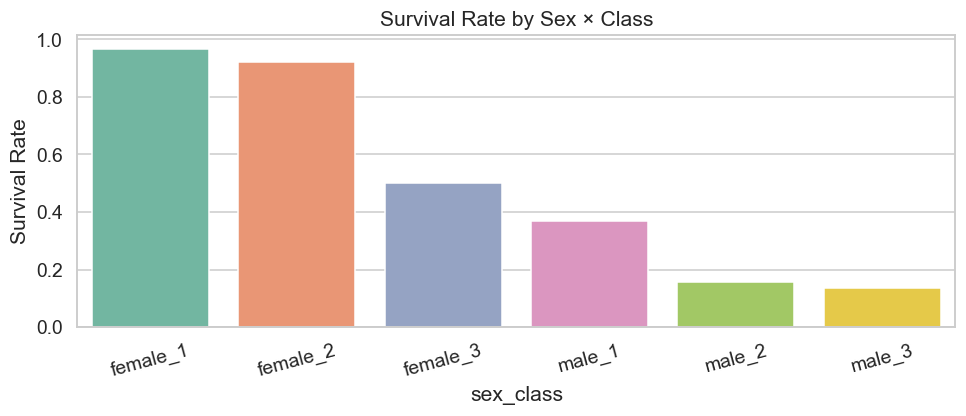

Observation: female_1 had ~97% survival; male_3 had ~13%.


In [47]:
plt.figure(figsize=(9, 4))
sns.barplot(data=sc_surv, x="sex_class", y="survived", palette="Set2")
plt.title("Survival Rate by Sex × Class")
plt.ylabel("Survival Rate")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("Observation: female_1 had ~97% survival; male_3 had ~13%.")


### 11b. Age × Class (Numeric Interaction)

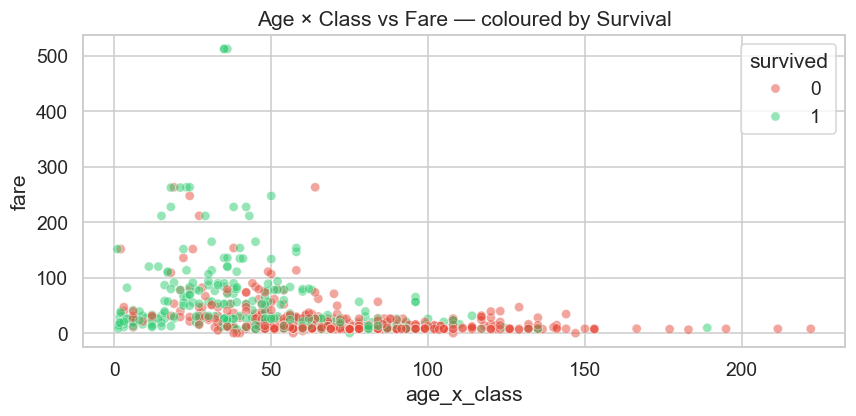

In [48]:
df["age_x_class"] = df["age"] * df["pclass"]

plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x="age_x_class", y="fare",
                hue="survived", palette={0:"#e74c3c", 1:"#2ecc71"}, alpha=0.5)
plt.title("Age × Class vs Fare — coloured by Survival")
plt.tight_layout()
plt.show()


### 11c. Alone × Class

In [49]:
df["alone_x_class"] = df["is_alone"] * df["pclass"]

print("Survival rate by alone_x_class:")
print(df.groupby("alone_x_class")["survived"].mean().round(3))


Survival rate by alone_x_class:
alone_x_class
0    0.506
1    0.532
2    0.346
3    0.213
Name: survived, dtype: float64


## 12. 🔢 Encoding Categorical Variables

All categorical features must be numeric before feeding into ML models.


In [30]:
# Binary mapping: sex
df["sex_encoded"] = df["sex"].map({"male": 0, "female": 1})
print("sex_encoded:", df["sex_encoded"].value_counts().to_dict())


sex_encoded: {0: 577, 1: 314}


In [31]:
# Binary mapping: adult_male
df["adult_male_encoded"] = df["adult_male"].astype(int)
print("adult_male_encoded:", df["adult_male_encoded"].value_counts().to_dict())


adult_male_encoded: {1: 537, 0: 354}


In [32]:
# One-hot encoding: embarked, age_group, fare_group, family_group, social_status
df_encoded = pd.get_dummies(
    df,
    columns=["embarked", "age_group", "fare_group", "family_group", "social_status"],
    drop_first=False,
    dtype=int
)

new_ohe = [c for c in df_encoded.columns if c not in df.columns]
print("New OHE columns:", new_ohe)


New OHE columns: ['embarked_C', 'embarked_Q', 'embarked_S', 'age_group_Child', 'age_group_Teen', 'age_group_Adult', 'age_group_Senior', 'fare_group_budget', 'fare_group_economy', 'fare_group_comfort', 'fare_group_luxury', 'family_group_alone', 'family_group_large', 'family_group_small', 'social_status_Child', 'social_status_Gentleman', 'social_status_Lady', 'social_status_Mr', 'social_status_Woman']


## 13. 📈 Correlation Analysis — What Predicts Survival?

With all features engineered, let's measure Pearson correlation with the target variable.


In [33]:
numeric_df = df_encoded.select_dtypes(include=[np.number])
surv_corr = (numeric_df.corr()["survived"]
               .drop("survived")
               .sort_values(key=abs, ascending=False))

print("Top 25 features by |r| with survived:")
print(surv_corr.head(25).to_string())


Top 25 features by |r| with survived:
status_encoded         0.606183
adult_male_encoded    -0.557080
is_female              0.543351
sex_encoded            0.543351
social_status_Mr      -0.529242
social_status_Lady     0.412074
pclass                -0.338481
log_fare               0.329862
age_x_class           -0.324559
has_cabin              0.319572
is_first_class         0.285904
family_group_small     0.279855
is_high_fare           0.274981
alone_x_class         -0.273747
social_status_Woman    0.269628
fare                   0.257307
fare_group_luxury      0.233638
fare_group_budget     -0.221610
fare_per_person        0.221600
family_group_alone    -0.203367
is_alone              -0.203367
embarked_C             0.168240
embarked_S            -0.149683
social_status_Child    0.136107
family_group_large    -0.125147


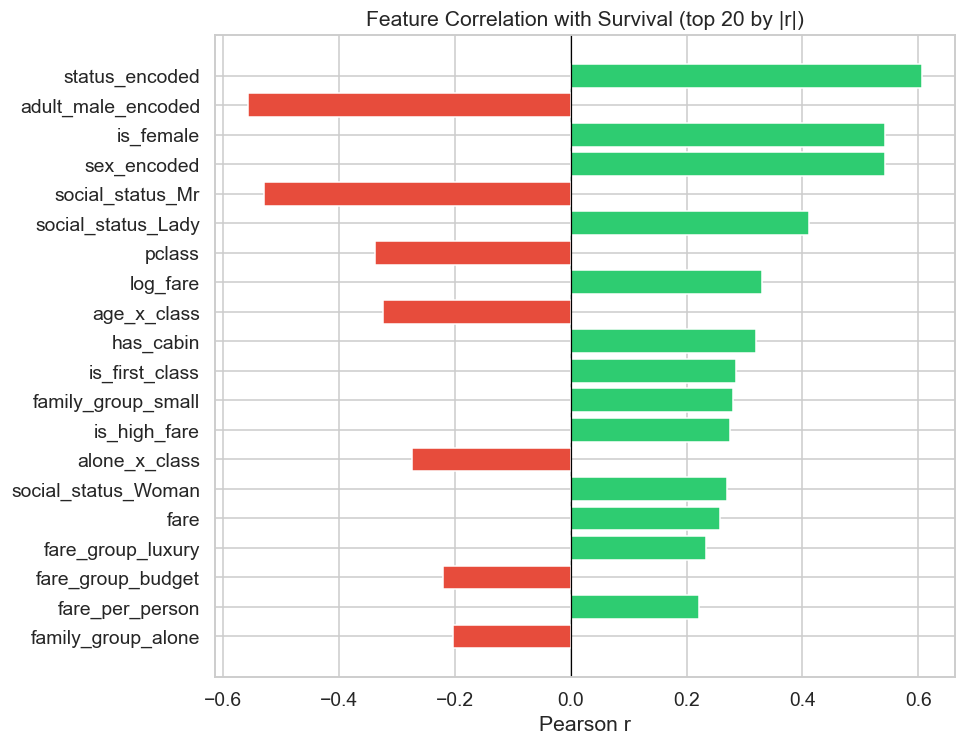

In [34]:
top_corr = surv_corr.head(20)
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in top_corr.values]

plt.figure(figsize=(9, 7))
plt.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Feature Correlation with Survival (top 20 by |r|)")
plt.xlabel("Pearson r")
plt.tight_layout()
plt.show()


In [ ]:
# Heatmap of key engineered features
key_feats = [
    "survived", "pclass", "sex_encoded", "age", "family_size",
    "is_alone", "fare_per_person", "log_fare", "fare_vs_class",
    "has_cabin", "is_child", "is_female", "is_first_class", "is_high_fare",
    "status_encoded", "age_x_class", "alone_x_class"
]

plt.figure(figsize=(13, 10))
corr = df_encoded[key_feats].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True)
plt.title("Correlation Heatmap — Engineered Features")
plt.tight_layout()
plt.show()


## 14. 📋 Final Feature Summary

In [35]:
print(f"Final DataFrame shape: {df_encoded.shape}")
print()
print("All columns:")
for i, col in enumerate(df_encoded.columns, 1):
    print(f"  {i:>3}. {col}")


Final DataFrame shape: (891, 44)

All columns:
    1. survived
    2. pclass
    3. sex
    4. age
    5. sibsp
    6. parch
    7. fare
    8. who
    9. adult_male
   10. alone
   11. has_cabin
   12. family_size
   13. is_alone
   14. status_encoded
   15. is_child
   16. is_female
   17. is_first_class
   18. is_high_fare
   19. fare_per_person
   20. log_fare
   21. sex_class
   22. age_x_class
   23. alone_x_class
   24. sex_encoded
   25. adult_male_encoded
   26. embarked_C
   27. embarked_Q
   28. embarked_S
   29. age_group_Child
   30. age_group_Teen
   31. age_group_Adult
   32. age_group_Senior
   33. fare_group_budget
   34. fare_group_economy
   35. fare_group_comfort
   36. fare_group_luxury
   37. family_group_alone
   38. family_group_large
   39. family_group_small
   40. social_status_Child
   41. social_status_Gentleman
   42. social_status_Lady
   43. social_status_Mr
   44. social_status_Woman


In [36]:
df_encoded.head(5)


,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,alone,...,fare_group_comfort,fare_group_luxury,family_group_alone,family_group_large,family_group_small,social_status_Child,social_status_Gentleman,social_status_Lady,social_status_Mr,social_status_Woman
0,0,3,male,22.0,1,0,7.2500,man,True,False,...,0,0,0,0,1,0,0,0,1,0
1,1,1,female,38.0,1,0,71.2833,woman,False,False,...,0,1,0,0,1,0,0,1,0,0
2,1,3,female,26.0,0,0,7.9250,woman,False,True,...,0,0,1,0,0,0,0,0,0,1
3,1,1,female,35.0,1,0,53.1000,woman,False,False,...,0,1,0,0,1,0,0,1,0,0
4,0,3,male,35.0,0,0,8.0500,man,True,True,...,0,0,1,0,0,0,0,0,1,0


---

## ✅ Summary of All Feature Engineering Techniques

| Feature | Type | Technique |
|---------|------|-----------|
| `family_size` | Numeric | Domain knowledge (sibsp + parch + 1) |
| `is_alone` | Binary | Logical / threshold |
| `family_group` | Categorical | Rule-based grouping |
| `has_cabin` | Binary | Missing-as-information |
| `social_status` | Categorical | Rule-based from who + sex + pclass |
| `status_encoded` | Numeric | Ordinal / target-informed encoding |
| `age_group` | Categorical | Uniform binning |
| `fare_group` | Categorical | Quantile binning (equal-frequency) |
| `is_child` | Binary | Rule-based threshold |
| `is_female` | Binary | Binary mapping |
| `is_first_class` | Binary | Rule-based threshold |
| `is_high_fare` | Binary | Median threshold |
| `fare_per_person` | Numeric | Ratio normalisation |
| `log_fare` | Numeric | Log transformation (skew correction) |
| `fare_vs_class` | Numeric | Group-relative ratio |
| `sex_class` | Categorical | Interaction feature (text) |
| `age_x_class` | Numeric | Multiplicative interaction |
| `alone_x_class` | Numeric | Multiplicative interaction |
| `sex_encoded` | Numeric | Binary mapping |
| `embarked_*` | Numeric | One-hot encoding |
| `age_group_*` | Numeric | One-hot encoding |
| `fare_group_*` | Numeric | One-hot encoding |
| `social_status_*` | Numeric | One-hot encoding |

> **Next step:** Drop `sex`, `who`, `social_status`, `sex_class`, `fare_group`, `age_group`, `family_group` (string versions) and pass the numeric columns into `sklearn`'s `RandomForestClassifier` or `LogisticRegression` to compare engineered vs raw features.
